# Franka：刚体模型激励轨迹对照

在 43 个刚体基参数上比较随机候选、论文中的 N=5 傅里叶系数，以及随机初值的 SLSQP 优化，并另设验证轨迹。此处使用解析 `q/dq/ddq`，README 的 62 基参数闭环筛选由 CLI 单独生成。

- 输入：无夹爪 `panda_arm.xml` 和 MDH 参数；优先读取 [modeling.ipynb](modeling.ipynb) 导出的 `outputs/franka_symbolic/franka_dynamics.py`，缺失时用数值回归。
- 输出：轨迹质量、位置/速度/加速度图，以及 `outputs/franka_symbolic/excitation/` 下的 `trajectories.npz`、`report.json`。
- 顺序：从上到下运行。第 4 节的 3 次 SLSQP 优化和第 5 节的验证搜索可能较慢；第 7 节写文件并覆盖同名文件。已有论文/SLSQP 输出可直接查看。

依赖：`pip install -e ".[sim,ident,viz,dev]"`。首个代码单元创建输出目录，需要另存时先修改 `OUT`。


In [8]:
import sys
from pathlib import Path

import numpy as np

def _project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (
            candidate / "src" / "robot_model" / "__init__.py"
        ).is_file():
            return candidate
    raise FileNotFoundError("找不到含 pyproject.toml 和 src/robot_model 的项目根目录")

_ROOT = _project_root(Path.cwd().resolve())
_SRC = _ROOT / "src"
if str(_SRC) not in sys.path:
    sys.path.insert(0, str(_SRC))

import mujoco

from robot_model import Robot
from robot_model.data import MotionData
from robot_model.excitation import (
    FourierTrajectory,
    generate_excitation_candidates,
    optimize_excitation,
    regressor_quality,
    search_excitation,
)
from robot_model.robots.franka import (
    PANDA_MDH_BODY_NAMES,
    PANDA_MDH_PARMS,
    panda_xml_path,
)
from robot_model.simulation.reference import MujocoReference, strip_to_rigid_body

OUT = _ROOT / "outputs" / "franka_symbolic" / "excitation"
OUT.mkdir(parents=True, exist_ok=True)
print("project:", _ROOT)
print("output :", OUT)


project: /home/xiaomeng/code/robot_model
output : /home/xiaomeng/code/robot_model/outputs/franka_symbolic/excitation


## 1. 模型与回归矩阵

读取已有刚体模型导出文件中的 `Hb`；若文件不存在，显式采用数值路径计算 43 个基参数，不生成完整符号表达式。


In [ ]:
robot = Robot.from_mdh("franka_panda_arm", PANDA_MDH_PARMS)
model = strip_to_rigid_body(mujoco.MjModel.from_xml_path(str(panda_xml_path())))
ref = MujocoReference(model, PANDA_MDH_BODY_NAMES)

lo = model.jnt_range[: robot.dof, 0].copy()
hi = model.jnt_range[: robot.dof, 1].copy()
for i in range(robot.dof):
    print(f"joint{i+1}: [{lo[i]:7.4f}, {hi[i]:7.4f}]")

py_path = _ROOT / "outputs" / "franka_symbolic" / "franka_dynamics.py"
if py_path.is_file():
    import importlib.util
    spec = importlib.util.spec_from_file_location("franka_dynamics", py_path)
    gen = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(gen)
    Hb_func = gen.Hb
    print("Hb from exported", py_path.name)
else:
    dyn = robot.dynamics
    dyn.calc_base_parms(numeric=True)
    dyn.gen_base_regressor()
    Hb_func = dyn.Hb_func
    print(f"Hb from numeric base parms  n_base={dyn.n_base}")


## 2. 随机候选评分

生成 20 条傅里叶轨迹，先缩放进关节限位，再用堆叠回归矩阵的条件数、秩和归一化最小奇异值比较。评分不使用力矩残差或参数真值。


In [10]:
rng = np.random.default_rng(0)

candidates = generate_excitation_candidates(
    robot.dof,
    rng,
    trials=20,
    frequencies=(0.10, 0.15, 0.20),
    harmonics=(3, 4, 5),
    vel_scale=0.8,
    limits=(lo, hi),
)

rows = []
for k, cand in enumerate(candidates):
    t = cand.timestamps(rate=100.0)
    q, dq, ddq = cand.evaluate(t)
    preview = MotionData(t, q, dq, ddq, np.zeros_like(q))
    qlt = regressor_quality(Hb_func, preview)
    rows.append({
        "idx": k,
        "f0": cand.base_freq,
        "Nh": cand.n_harmonics,
        "traj": cand,
        **qlt,
    })

rows.sort(key=lambda r: r["condition_number"])
print(f"{'#':>3} {'f0':>5} {'Nh':>3} {'rank':>7} {'cond':>10} {'sig_min/sqrtN':>14}")
for r in rows[:10]:
    print(
        f"{r['idx']:3d} {r['f0']:5.2f} {r['Nh']:3d} "
        f"{r['rank']:3d}/{r['n_parms']:<3d} "
        f"{r['condition_number']:10.3g} "
        f"{r['min_singular_value']:14.3g}"
    )

best = rows[0]
train_traj = best["traj"]
train_cond = best["condition_number"]
print(
    f"\nTRAIN #{best['idx']}: cond={train_cond:.3g}  "
    f"f0={train_traj.base_freq:.2f}  Nh={train_traj.n_harmonics}"
)


  #    f0  Nh    rank       cond  sig_min/sqrtN
 19  0.15   4  43/43         199          0.117
  8  0.10   4  43/43         203         0.0864
  6  0.20   3  43/43         361         0.0717
  4  0.20   5  43/43         439         0.0545
  1  0.15   4  43/43         447         0.0553
 11  0.20   5  43/43         529         0.0503
  2  0.15   3  43/43         565          0.042
 18  0.20   4  43/43         570         0.0444
  0  0.15   5  43/43         618         0.0392
 10  0.10   3  43/43         649         0.0334

TRAIN #19: cond=199  f0=0.15  Nh=4


## 3. 论文系数对照

保留原有 N=5 系数，基频为 `f0 = 0.15π / 2π = 0.075 Hz`。将轨迹缩放进当前模型的关节限位后，与第 2 节最佳随机候选比较。本节评估的是这些系数在当前模型、采样率和回归矩阵下的表现。


In [11]:
# 论文里的傅里叶系数（Nh=5）：那边存的是 (Nh, dof)，
# 这里 FourierTrajectory 要 (dof, Nh)，所以转置一下。
a_paper = np.array([
    [-0.2031, -0.0699, 0.3076, 0.1269, 0.5864, -0.0253, -0.2773],
    [0.1295, -0.5380, 0.2100, -0.2273, -0.0857, -0.1194, -0.2015],
    [-0.0090, 0.4810, -0.0950, 0.2319, -0.5535, -0.2099, -0.1228],
    [0.2178, 0.5311, -0.0964, -0.2405, 0.4810, -0.0950, 0.2319],
    [-0.7598, 0.2352, 0.5725, -0.5273, 0.6984, -0.1639, -0.0399],
])
b_paper = np.array([
    [-0.1136, -0.2437, 0.6600, 0.1820, 0.3898, 0.0401, 0.5491],
    [0.0692, 0.2023, -0.0268, -0.1503, 0.1046, -0.6946, -0.2570],
    [-0.5010, -0.1858, -0.2390, 0.0179, 0.2359, 0.0407, -0.4442],
    [0.1867, -0.2647, 0.4767, -0.2022, -0.0432, -0.5749, 0.0774],
    [0.2357, 0.4252, 0.2726, 0.3693, 0.2448, -0.0698, -0.4833],
])
q0_paper = np.array([-0.5850, -0.1744, -0.3373, -1.8767, -1.0631, 1.7917, -0.7284])
f0_paper = (0.15 * np.pi) / (2.0 * np.pi)  # 0.075 Hz

paper_traj = FourierTrajectory(
    q0=q0_paper, a=a_paper.T, b=b_paper.T, base_freq=f0_paper,
).fit_limits(lo, hi, rate=100.0)

t = paper_traj.timestamps(rate=100.0)
q, dq, ddq = paper_traj.evaluate(t)
paper_qlt = regressor_quality(Hb_func, MotionData(t, q, dq, ddq, np.zeros_like(q)))
paper_cond = paper_qlt["condition_number"]

print(
    f"PAPER  f0={paper_traj.base_freq:.4f} Hz  Nh={paper_traj.n_harmonics}  "
    f"cond={paper_cond:.3g}  rank={paper_qlt['rank']}/{paper_qlt['n_parms']}  "
    f"sig_min/sqrtN={paper_qlt['min_singular_value']:.3g}"
)
print(f"TRAIN (random best) cond={train_cond:.3g}")
print(f"PAPER / TRAIN ratio = {paper_cond / train_cond:.3f}x  (smaller is better)")
print("in limits:", bool((q >= lo).all() and (q <= hi).all()))


PAPER  f0=0.0750 Hz  Nh=5  cond=50.2  rank=43/43  sig_min/sqrtN=0.382
TRAIN (random best) cond=199
PAPER / TRAIN ratio = 0.252x  (smaller is better)
in limits: True


## 4. SLSQP 约束优化

慢速单元：使用 3 个随机初值，每次最多 30 次迭代。固定 N=5、`f0=0.075 Hz`，对傅里叶系数最小化 $\log\kappa(W)$，并约束位置、速度和加速度。采用代码中列出的 Franka 规格量级限制；随机初值独立于论文系数，结果是局部优化解。


In [12]:
# Franka 手册里的关节速度 / 加速度限位（rad/s，rad/s^2）
vel_lim = np.array([2.175, 2.175, 2.175, 2.175, 2.610, 2.610, 2.610])
acc_lim = np.array([15.0, 7.5, 10.0, 12.5, 15.0, 20.0, 20.0])

# 随机给一条初值轨迹（Nh=5，f0=0.075，和论文参数对齐，方便对照）
rng_opt = np.random.default_rng(7)
n_starts = 3
opt_results = []

for s in range(n_starts):
    init = FourierTrajectory.random(
        robot.dof,
        rng_opt,
        n_harmonics=5,
        base_freq=0.075,
        vel_scale=0.8,
    ).fit_limits(lo, hi, rate=100.0)

    t0 = init.timestamps(rate=100.0)
    q0_, dq0, ddq0 = init.evaluate(t0)
    qlt0 = regressor_quality(
        Hb_func, MotionData(t0, q0_, dq0, ddq0, np.zeros_like(q0_))
    )
    cond0 = qlt0["condition_number"]

    opt = optimize_excitation(
        Hb_func,
        init,
        limits=(lo, hi),
        velocity_limits=vel_lim,
        acceleration_limits=acc_lim,
        maxiter=30,
        samples=128,
    )
    traj_opt = opt.trajectory
    t1 = traj_opt.timestamps(rate=100.0)
    q1, dq1, ddq1 = traj_opt.evaluate(t1)
    qlt1 = regressor_quality(
        Hb_func, MotionData(t1, q1, dq1, ddq1, np.zeros_like(q1))
    )
    cond1 = qlt1["condition_number"]
    opt_results.append({
        "start": s,
        "init": init,
        "traj": traj_opt,
        "cond0": cond0,
        "cond1": cond1,
        "rank": qlt1["rank"],
        "n_parms": qlt1["n_parms"],
        "report": opt.report,
    })
    print(
        f"start#{s}: cond {cond0:.3g} -> {cond1:.3g}  "
        f"rank={qlt1['rank']}/{qlt1['n_parms']}  "
        f"adopted={opt.report.get('adopted', opt.report)}"
    )

best_opt = min(opt_results, key=lambda r: r["cond1"])
opt_traj = best_opt["traj"]
opt_cond = best_opt["cond1"]
print(
    f"\nBEST optimized: start#{best_opt['start']}  cond={opt_cond:.3g}  "
    f"(init was {best_opt['cond0']:.3g})"
)
print(
    f"compare  TRAIN={train_cond:.3g}  PAPER={paper_cond:.3g}  OPT={opt_cond:.3g}"
)


start#0: cond 307 -> 16.2  rank=43/43  adopted=True
start#1: cond 335 -> 14  rank=43/43  adopted=True
start#2: cond 300 -> 18  rank=43/43  adopted=True

BEST optimized: start#1  cond=14  (init was 335)
compare  TRAIN=199  PAPER=50.2  OPT=14


## 5. 独立验证轨迹

使用另一随机种子搜索验证轨迹，评价仍只看回归矩阵。这次 `search_excitation` 保留默认 SLSQP 精炼，可能较慢。


In [5]:
val_traj, val_cond = search_excitation(
    Hb_func,
    robot.dof,
    np.random.default_rng(1),
    trials=20,
    vel_scale=0.8,
    limits=(lo, hi),
)
print(f"VAL  cond={val_cond:.3g}  f0={val_traj.base_freq:.2f}  Nh={val_traj.n_harmonics}")
print(f"TRAIN cond={train_cond:.3g}  VAL cond={val_cond:.3g}")


VAL  cond=144  f0=0.10  Nh=5
TRAIN cond=199  VAL cond=144


## 6. 轨迹图

依次绘制 TRAIN（最佳随机候选）、PAPER（N=5 系数）、OPT（随机初值 SLSQP）和 VAL。每组显示位置、速度、加速度，并输出限位检查和峰值。


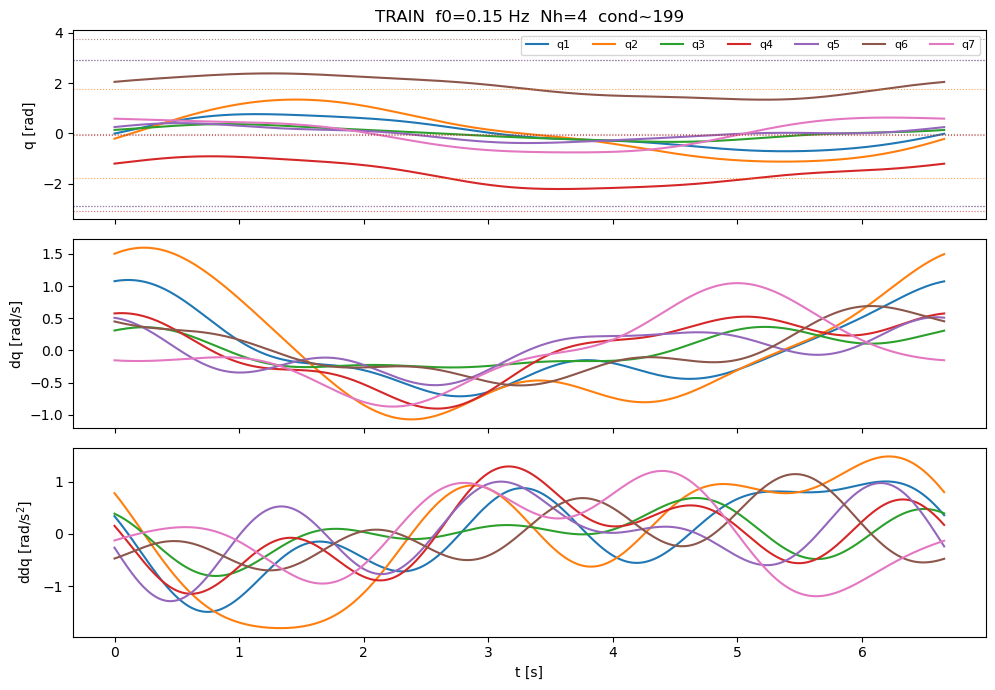

in limits: True
peak |dq| : [1.095 1.597 0.365 0.905 0.541 0.689 1.045]
peak |ddq|: [1.487 1.798 0.802 1.29  1.283 1.144 1.205]


In [6]:
import matplotlib.pyplot as plt

def plot_traj(traj, title, limits=None):
    t = traj.timestamps(rate=100.0)
    q, dq, ddq = traj.evaluate(t)
    fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
    for i in range(traj.dof):
        axes[0].plot(t, q[:, i], label=f"q{i+1}")
        axes[1].plot(t, dq[:, i], label=f"dq{i+1}")
        axes[2].plot(t, ddq[:, i], label=f"ddq{i+1}")
    if limits is not None:
        lo_, hi_ = limits
        for i in range(traj.dof):
            axes[0].axhline(lo_[i], color=f"C{i}", ls=":", lw=0.8, alpha=0.7)
            axes[0].axhline(hi_[i], color=f"C{i}", ls=":", lw=0.8, alpha=0.7)
    axes[0].set_ylabel("q [rad]")
    axes[1].set_ylabel("dq [rad/s]")
    axes[2].set_ylabel(r"ddq [rad/s$^2$]")
    axes[2].set_xlabel("t [s]")
    axes[0].set_title(title)
    axes[0].legend(ncol=7, fontsize=8, loc="upper right")
    fig.tight_layout()
    plt.show()
    in_lim = bool((q >= lo).all() and (q <= hi).all()) if limits is not None else None
    print("in limits:", in_lim)
    print("peak |dq| :", np.round(np.abs(dq).max(axis=0), 3))
    print("peak |ddq|:", np.round(np.abs(ddq).max(axis=0), 3))

plot_traj(
    train_traj,
    f"TRAIN  f0={train_traj.base_freq:.2f} Hz  Nh={train_traj.n_harmonics}  cond~{train_cond:.3g}",
    limits=(lo, hi),
)


In [ ]:
plot_traj(
    paper_traj,
    f"PAPER N=5  f0={paper_traj.base_freq:.4f}  Nh={paper_traj.n_harmonics}  cond~{paper_cond:.3g}",
    limits=(lo, hi),
)


In [ ]:
plot_traj(
    opt_traj,
    f"OPT (random init + SLSQP)  f0={opt_traj.base_freq:.4f}  Nh={opt_traj.n_harmonics}  cond~{opt_cond:.3g}",
    limits=(lo, hi),
)


In [ ]:
plot_traj(
    val_traj,
    f"VAL  f0={val_traj.base_freq:.2f}  Nh={val_traj.n_harmonics}  cond~{val_cond:.3g}",
    limits=(lo, hi),
)


## 7. 保存轨迹与比较结果

写文件：将四条轨迹的傅里叶系数保存到 `OUT / "trajectories.npz"`，条件数、约束和轨迹信息保存到 `OUT / "report.json"`。再次执行会覆盖同名文件；后续脚本可自行读取这些系数。


In [ ]:
import json

np.savez_compressed(
    OUT / "trajectories.npz",
    train_q0=train_traj.q0, train_a=train_traj.a, train_b=train_traj.b,
    train_freq=train_traj.base_freq,
    paper_q0=paper_traj.q0, paper_a=paper_traj.a, paper_b=paper_traj.b,
    paper_freq=paper_traj.base_freq,
    opt_q0=opt_traj.q0, opt_a=opt_traj.a, opt_b=opt_traj.b,
    opt_freq=opt_traj.base_freq,
    val_q0=val_traj.q0, val_a=val_traj.a, val_b=val_traj.b,
    val_freq=val_traj.base_freq,
)

def traj_dict(tr):
    return {
        "q0": tr.q0.tolist(),
        "a": tr.a.tolist(),
        "b": tr.b.tolist(),
        "base_freq": float(tr.base_freq),
    }

report = {
    "train_condition_number": float(train_cond),
    "paper_condition_number": float(paper_cond),
    "opt_condition_number": float(opt_cond),
    "opt_init_condition_number": float(best_opt["cond0"]),
    "opt_n_starts": n_starts,
    "val_condition_number": float(val_cond),
    "joint_lower": lo.tolist(),
    "joint_upper": hi.tolist(),
    "velocity_limits": vel_lim.tolist(),
    "acceleration_limits": acc_lim.tolist(),
    "train": traj_dict(train_traj),
    "paper": traj_dict(paper_traj),
    "optimized": traj_dict(opt_traj),
    "validation": traj_dict(val_traj),
    "method": "random search + paper N=5 + SLSQP optimize from random inits",
}
(OUT / "report.json").write_text(
    json.dumps(report, ensure_ascii=False, indent=2), encoding="utf-8"
)
print("saved to", OUT.resolve())
for f in sorted(OUT.iterdir()):
    print(f"  {f.name:20s} {f.stat().st_size/1024:7.1f} KB")
